# 🎬 Movie Rating Prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
movies_df = pd.read_csv("IMDb Movies India.csv", encoding='ISO-8859-1')
movies_df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
1,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
2,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
3,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
4,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [3]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5659 entries, 0 to 5658
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   int64  
 2   Duration  5659 non-null   int64  
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   int64  
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 442.2+ KB


# Missing Values

In [5]:
movies_df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

# 🧹 Clean Votes and Clean Year

In [6]:
movies_df['Votes'] = movies_df['Votes'].astype(str).str.replace(',', '', regex=False)
movies_df['Votes'] = pd.to_numeric(movies_df['Votes'], errors='coerce')

In [7]:
movies_df['Year'] = movies_df['Year'].astype(str).str.extract(r'(\d+)')
movies_df['Year'] = pd.to_numeric(movies_df['Year'], errors='coerce')

In [8]:
movies_df['Duration'] = movies_df['Duration'].astype(str).str.replace(' min', '', regex=False)
movies_df['Duration'] = pd.to_numeric(movies_df['Duration'], errors='coerce')

# Fill Missing Values

In [9]:
movies_df = movies_df.fillna({
    'Votes': movies_df['Votes'].median(),
    'Year': movies_df['Year'].median(),
    'Duration': movies_df['Duration'].median(),
    'Rating': movies_df['Rating'].median(),
    'Genre': 'Unknown',
    'Director': 'Unknown',
    'Actor 1': 'Unknown',
    'Actor 2': 'Unknown',
    'Actor 3': 'Unknown'
})

# 📊 Top 10 Movies

In [10]:
top_movies = movies_df.sort_values(by='Rating', ascending=False).head(10)
top_movies[['Name','Rating']]

,Name,Rating
3146,Love Qubool Hai,10.0
2027,Half Songs,9.7
2574,June,9.4
5165,The Reluctant Crime,9.4
1897,Gho Gho Rani,9.4
536,Ashok Vatika,9.3
4783,Sindhustan,9.3
3149,Love Sorries,9.3
4609,Secrets of Sinauli,9.3
4321,Refl3ct,9.3


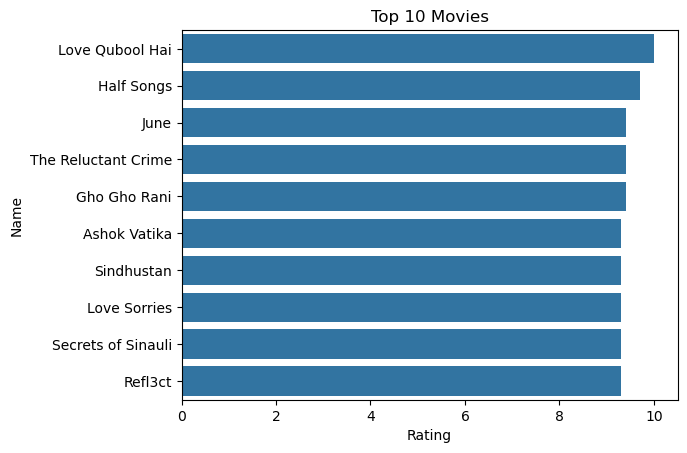

In [11]:
sns.barplot(x='Rating', y='Name', data=top_movies)
plt.title("Top 10 Movies")
plt.show()


# 📊 Top Movies by Year

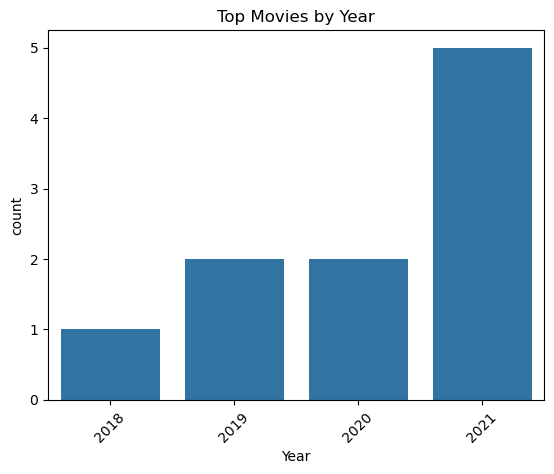

In [12]:
sns.countplot(x='Year', data=top_movies)
plt.xticks(rotation=45)
plt.title("Top Movies by Year")
plt.show()

# 📊 Genre Distribution

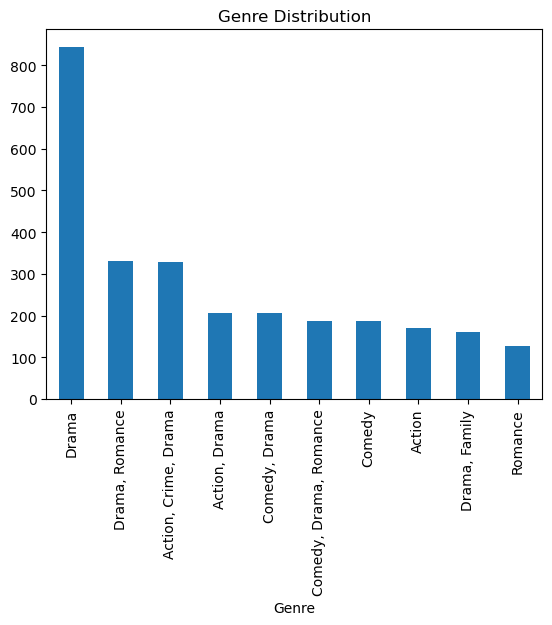

In [13]:
movies_df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Genre Distribution")
plt.show()

# 📊 Top Directors

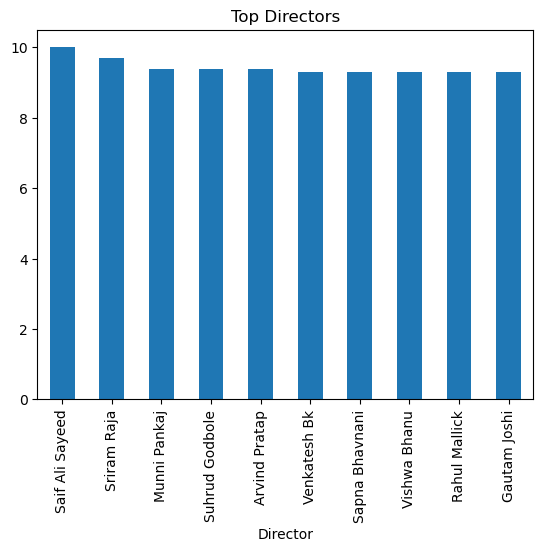

In [14]:
movies_df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Directors")
plt.show()

# 📊 Votes vs Rating

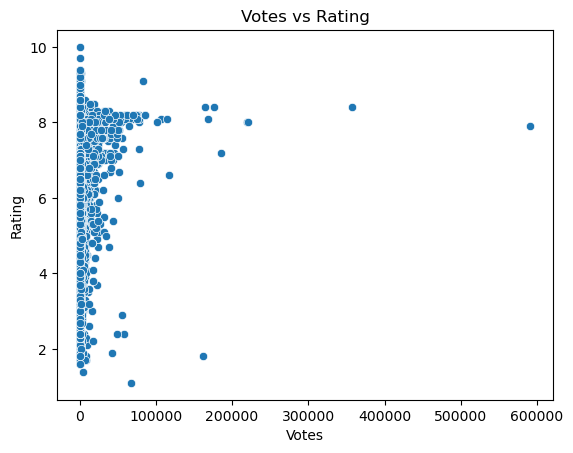

In [15]:
sns.scatterplot(x='Votes', y='Rating', data=movies_df)
plt.title("Votes vs Rating")
plt.show()

# 📊 Top Actors

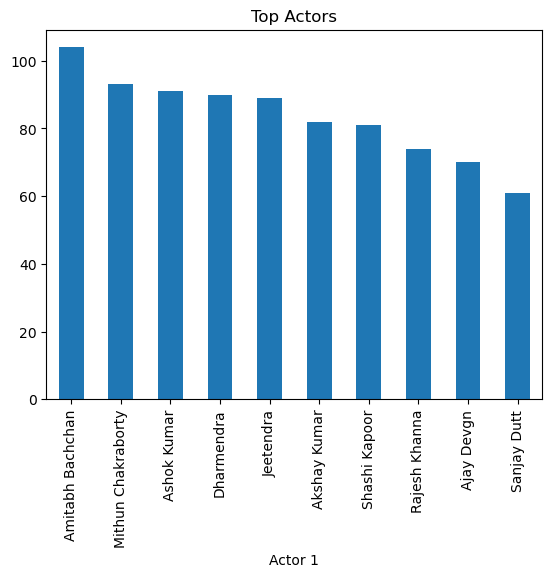

In [16]:
movies_df['Actor 1'].value_counts().head(10).plot(kind='bar')
plt.title("Top Actors")
plt.show()


# 📊 Movies per Year

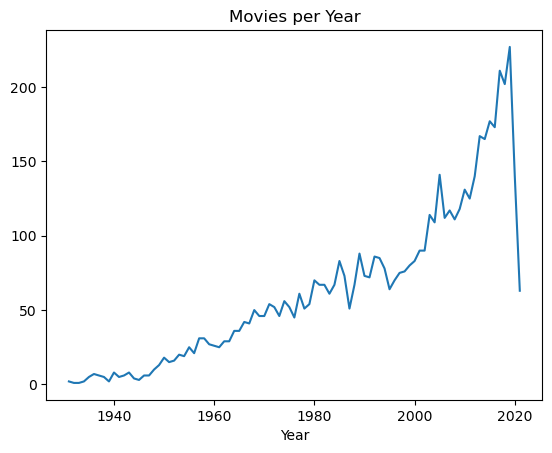

In [17]:
movies_df['Year'].value_counts().sort_index().plot()
plt.title("Movies per Year")
plt.show()

# 📊 High Rated Movies

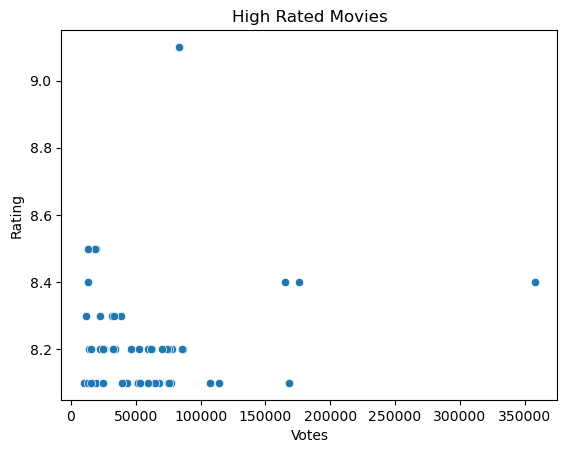

In [18]:
high_movies = movies_df[(movies_df['Rating'] > 8) & (movies_df['Votes'] > 10000)]
sns.scatterplot(x='Votes', y='Rating', data=high_movies)
plt.title("High Rated Movies")
plt.show()


# 📊 Duration vs Year

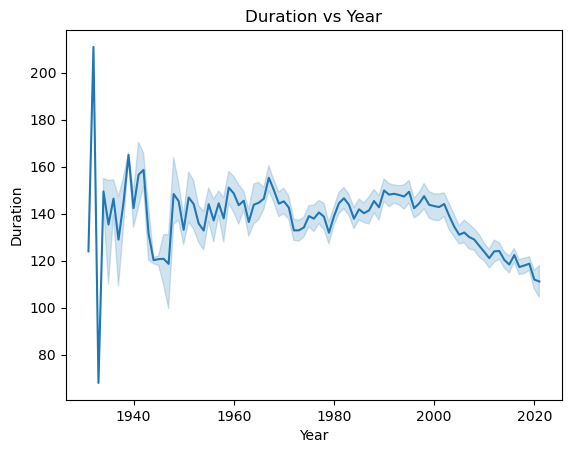

In [19]:
sns.lineplot(x='Year', y='Duration', data=movies_df)
plt.title("Duration vs Year")
plt.show()


# 📊 Average rating per Genre

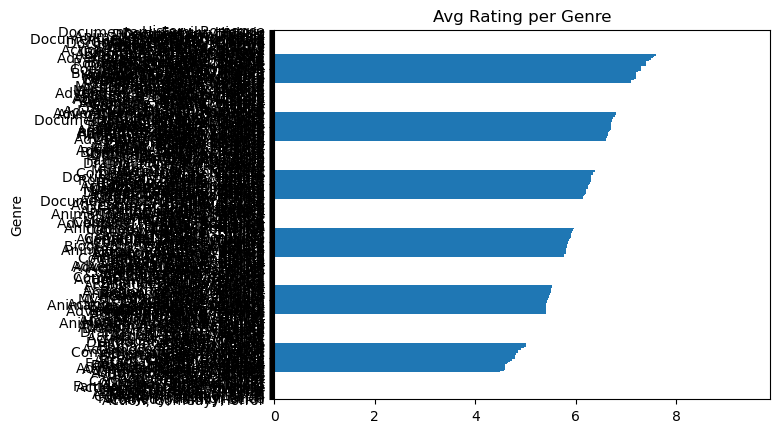

In [20]:
movies_df.groupby('Genre')['Rating'].mean().sort_values().plot(kind='barh')
plt.title("Avg Rating per Genre")
plt.show()


# ⚙️ Feature Engineering

In [21]:
movies_df = movies_df[['Year','Votes','Duration','Rating']]

# 📊 Correlation Heatmap

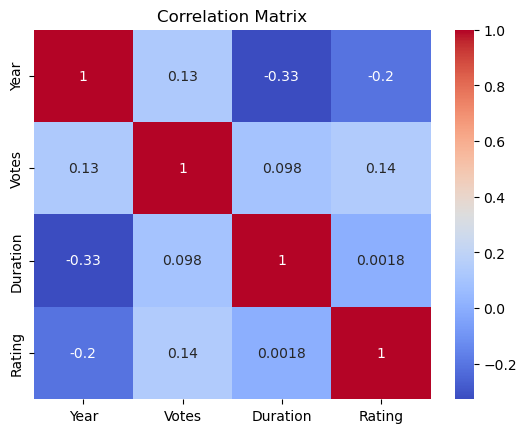

In [22]:
sns.heatmap(movies_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X = movies_df[['Year','Votes','Duration']]
y = movies_df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model Training

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 📈 Prediction and Evaluation

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1.7072912137275804


# 📊 Actual vs Predicted

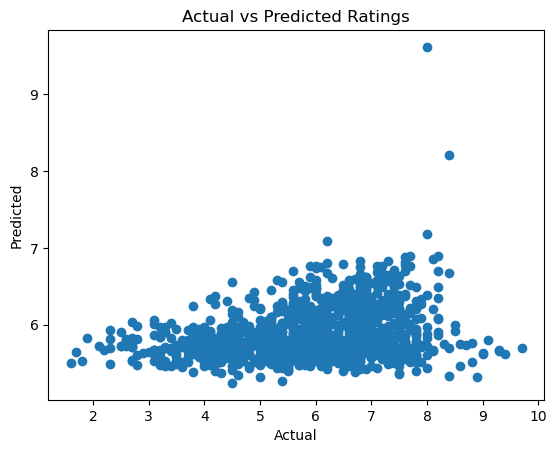

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()


## Conclusion
- Votes and duration influence movie ratings
- Popular movies tend to have higher ratings
- Linear regression provides reasonable predictions